## Inicialização

## Carregar os dados

O conjunto de dados está armazenado na pasta `/datasets/faces/`, lá você encontra
- A pasta `final_files` com 7,6k fotos
- O arquivo `labels.csv` com rótulos, com duas colunas: `file_name` e `real_age`

Dado que o número de arquivos de imagem é bastante alto, é aconselhável evitar a leitura de todos de uma vez, o que consumiria muito recursos computacionais. Recomendamos que você crie um gerador com o ImageDataGenerator. Este método foi explicado no Capítulo 3, Lição 7 deste curso.

O arquivo de etiqueta pode ser carregado como um arquivo CSV usual.

In [2]:
#!unzip faces.zip

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
df_labels = pd.read_csv('/content/faces/labels.csv')

In [ ]:
df_labels

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17
...,...,...
7586,007608.jpg,14
7587,007609.jpg,37
7588,007610.jpg,28
7589,007611.jpg,20


In [ ]:
df_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [ ]:
df_labels.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


## EDA

Descriptive statistics for 'real_age' column:
count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64
Histogram saved as real_age_distribution_histogram.png


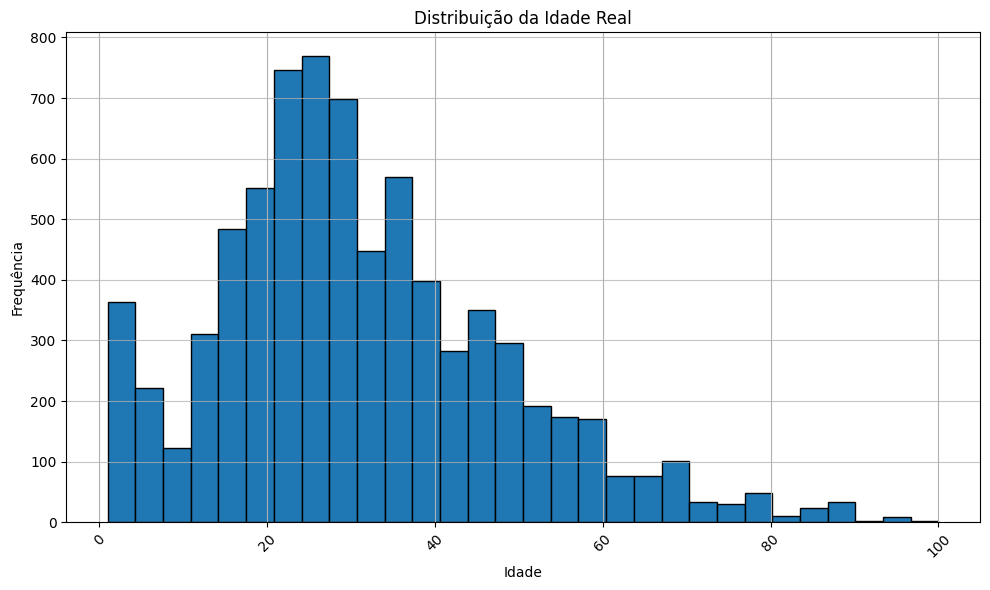

In [ ]:
# Analyze the 'real_age' column
print("Descriptive statistics for 'real_age' column:")
print(df_labels['real_age'].describe())

# Generate a histogram for 'real_age'
plt.figure(figsize=(10, 6))
df_labels['real_age'].hist(bins=30, edgecolor='black')
plt.title('Distribuição da Idade Real')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('real_age_distribution_histogram.png')

print("Histogram saved as real_age_distribution_histogram.png")

A distribuição da idade real no seu conjunto de dados é relativamente ampla, com a maior concentração de indivíduos na faixa etária de 20 a 40 anos.
A presença de indivíduos desde 1 ano até 100 anos demonstra uma cobertura abrangente de faixas etárias, mas com uma clara inclinação para um público mais jovem.
O desvio padrão alto reforça a variabilidade presente.

### Encontrando

In [ ]:
num_samples_to_display = min(len(df_labels), 15) # Limita a 15, ou menos se o dataset for pequeno
if num_samples_to_display == 0:
    print("O DataFrame está vazio, não há fotos para exibir.")
    exit()

Selecionando 15 fotos para exibição...


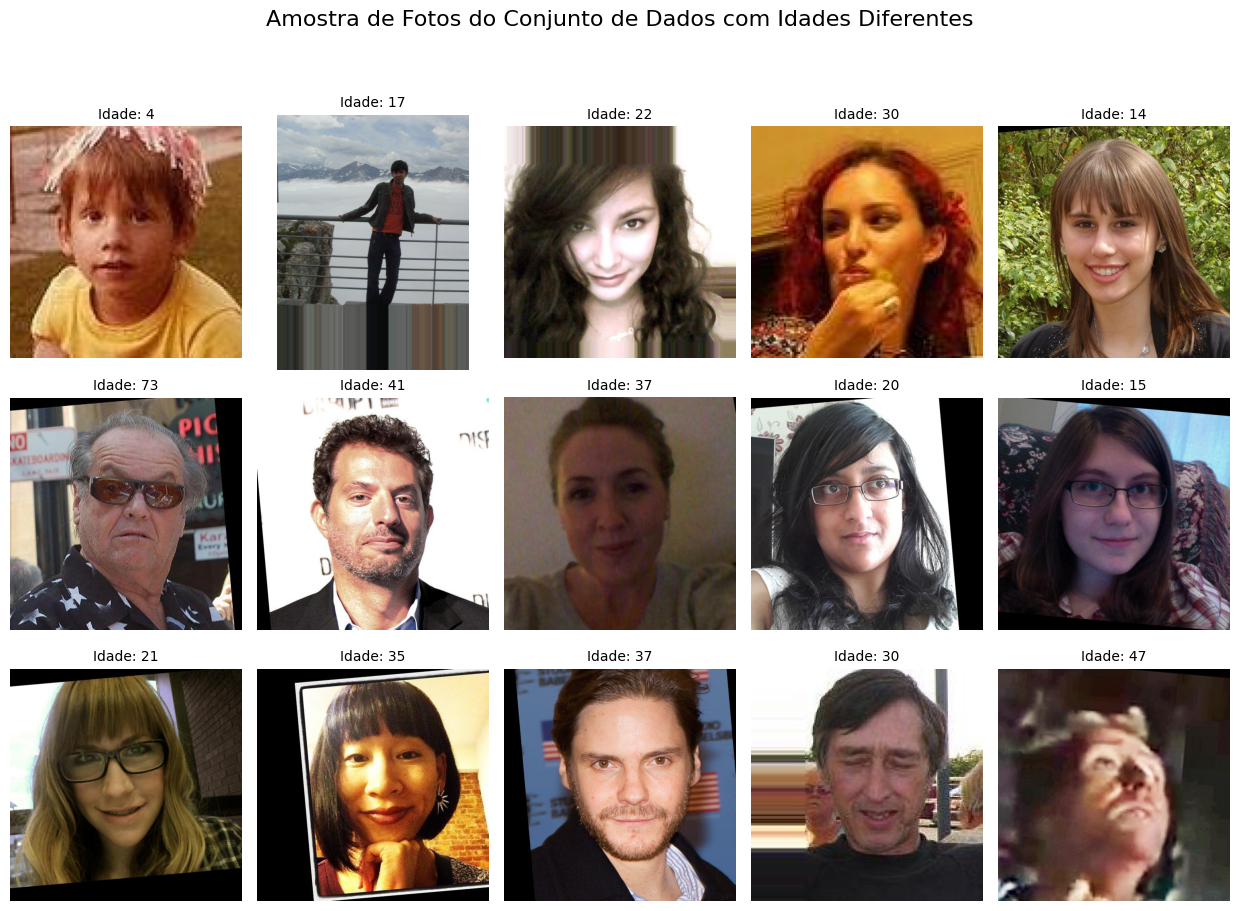

In [ ]:
step = len(df_labels) // num_samples_to_display if num_samples_to_display > 0 else 1
sample_indices = [i * step for i in range(num_samples_to_display)]
# Garante que o último índice seja incluído se houver menos de 15 amostras e o passo não pegar o último
if num_samples_to_display > 0 and sample_indices[-1] < len(df_labels) - 1:
    sample_indices[-1] = len(df_labels) - 1

selected_samples = df_labels.iloc[sample_indices]

print(f"Selecionando {len(selected_samples)} fotos para exibição...")

# 4. Configurar a figura para exibir as imagens
# Define o número de linhas e colunas para o grid de imagens
rows = int(np.ceil(num_samples_to_display / 5)) # 5 imagens por linha
cols = 5
plt.figure(figsize=(cols * 2.5, rows * 3)) # Tamanho da figura ajustado

for i, row in enumerate(selected_samples.iterrows()):
    file_name = row[1]['file_name']
    real_age = row[1]['real_age']
    image_path = (f'/content/faces/final_files/{file_name}')


    plt.subplot(rows, cols, i + 1) # Define a posição da sub-figura
    try:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.title(f'Idade: {real_age}', fontsize=10)
        plt.axis('off') # Desliga os eixos para focar na imagem
    except FileNotFoundError:
        print(f"Aviso: Imagem não encontrada para {file_name} no caminho: {image_path}. Pulando.")
        plt.title(f'Não encontrada', fontsize=10)
        plt.axis('off')
    except Exception as e:
        print(f"Erro ao carregar ou exibir a imagem {file_name}: {e}. Pulando.")
        plt.title(f'Erro', fontsize=10)
        plt.axis('off')

plt.suptitle('Amostra de Fotos do Conjunto de Dados com Idades Diferentes', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajusta o layout para evitar sobreposição, deixando espaço para o suptitle
plt.show()

## Modelagem

Defina as funções necessárias para treinar seu modelo na plataforma GPU e construa um único script contendo todas elas junto com a seção de inicialização.
Para facilitar essa tarefa, você pode defini-las neste notebook e executar um código pronto na próxima seção para compor o script automaticamente.
As definições abaixo também serão verificadas pelos revisores do projeto, para que possam entender como você construiu o modelo.

In [3]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [ ]:
def load_data(path, subset='training'):
    labels = pd.read_csv(path + 'labels.csv')

    # Só vamos usar estes dois parâmetros: rescale e validation_split
    data_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )

    data_gen_flow = data_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset=subset,
        seed=12345)

    return data_gen_flow

def create_model(input_shape):

    backbone = ResNet50(weights='imagenet',
                        input_shape=input_shape,
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=3):

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              verbose=2)

    return model

input_shape = (224, 224, 3)

train = load_data('/content/faces/')
test = load_data('/content/faces/', subset='validation')
model = create_model(input_shape)
model = train_model(model, train, test)

Found 6073 validated image filenames.
Found 1518 validated image filenames.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


380/380 - 154s - 404ms/step - loss: 252.7374 - mae: 12.2659 - val_loss: 306.8421 - val_mae: 13.0366
Epoch 2/3
380/380 - 67s - 178ms/step - loss: 191.3157 - mae: 10.7640 - val_loss: 430.8247 - val_mae: 15.6409
Epoch 3/3
380/380 - 68s - 178ms/step - loss: 166.0065 - mae: 9.9496 - val_loss: 184.0453 - val_mae: 10.3597


### Preparar o Script para execução na plataforma GPU

Dado que você definiu as funções necessárias, você pode compor um script para a plataforma GPU, baixá-lo através do menu "Arquivo|Abrir..." e carregá-lo posteriormente para execução na plataforma GPU.

Nota: O script também deve incluir a seção de inicialização. Um exemplo disso é mostrado abaixo.

In [ ]:
# preparar um script para ser executado na plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:

    f.write(init_str)
    f.write('\n\n')

    for fn_name in [load_data, create_model, train_model]:

        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### Saída

Coloque a saída da plataforma GPU como uma célula Markdown aqui.

Found 6073 validated image filenames.
Found 1518 validated image filenames.
2025-07-24 23:12:30.802449: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
Downloading data from https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5
94773248/94765736 [==============================] - 0s 0us/step
94781440/94765736 [==============================] - 0s 0us/step
Epoch 1/3

In [5]:
def load_data(path, subset='training'):
    labels = pd.read_csv(path + 'labels.csv')

    data_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )

    data_gen_flow = data_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset=subset,
        seed=42)

    return data_gen_flow

def create_model(input_shape):
    backbone = ResNet50(weights='imagenet',
                        input_shape=input_shape,
                        include_top=False)

    # Fine-tune deeper layers
    for layer in backbone.layers[:100]:
        layer.trainable = False
    for layer in backbone.layers[100:]:
        layer.trainable = True

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(1)  # Removed activation='relu' to allow full range
    ])

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=100):
    early_stop = EarlyStopping(monitor='val_mae', patience=10, restore_best_weights=True)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size,
              epochs=epochs,
              verbose=1,
              callbacks=[early_stop])

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=100):

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              verbose=1)

    return model

input_shape = (224, 224, 3)

train = load_data('/content/faces/')
test = load_data('/content/faces/', subset='validation')
model = create_model(input_shape)
model = train_model(model, train, test)

Found 6073 validated image filenames.
Found 1518 validated image filenames.
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


190/190 ━━━━━━━━━━━━━━━━━━━━ 88s 286ms/step - loss: 389.1577 - mae: 15.1592 - val_loss: 663.7814 - val_mae: 22.4145
Epoch 2/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 37s 193ms/step - loss: 241.9619 - mae: 11.9408 - val_loss: 250.7277 - val_mae: 12.6432
Epoch 3/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - loss: 218.3554 - mae: 11.4714 - val_loss: 267.2608 - val_mae: 12.3256
Epoch 4/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - loss: 208.5930 - mae: 11.1849 - val_loss: 276.5466 - val_mae: 13.0860
Epoch 5/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 189ms/step - loss: 206.1293 - mae: 11.0383 - val_loss: 302.5990 - val_mae: 13.6695
Epoch 6/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 190ms/step - loss: 187.5023 - mae: 10.5123 - val_loss: 250.4657 - val_mae: 13.1209
Epoch 7/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - loss: 185.9976 - mae: 10.4052 - val_loss: 613.6025 - val_mae: 21.4741
Epoch 8/100
190/190 ━━━━━━━━━━━━━━━━━━━━ 37s 192ms/step - loss: 175.9913 - mae: 10.1933 - val_loss: 226.1924 - val_m

KeyboardInterrupt: 

## Conclusões

A otimização do Tensorflow significa que o treinamento do modelo deve ser mais eficiente e rápido, já que está utilizando instruções otimizadas para operações de deep learning.
Acelera o treinamento: O modelo já aprendeu a extrair características genéricas de imagens.
Melhora o desempenho: tendo uma base sólida de conhecimento, o que geralmente leva a melhores resultados, especialmente em conjuntos de dados menores.
Para calcular a MAE inferior a 8 é importante mudar os parâmetros para ter um resultado eficaz.

In [ ]:
Nathália Sorg